<img src="logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 1

Autor: *MARCHESI, Matías Sebastián*


## Introducción

En esta tarea se busca, partiendo de este circuito:
<div style="text-align: center;">
  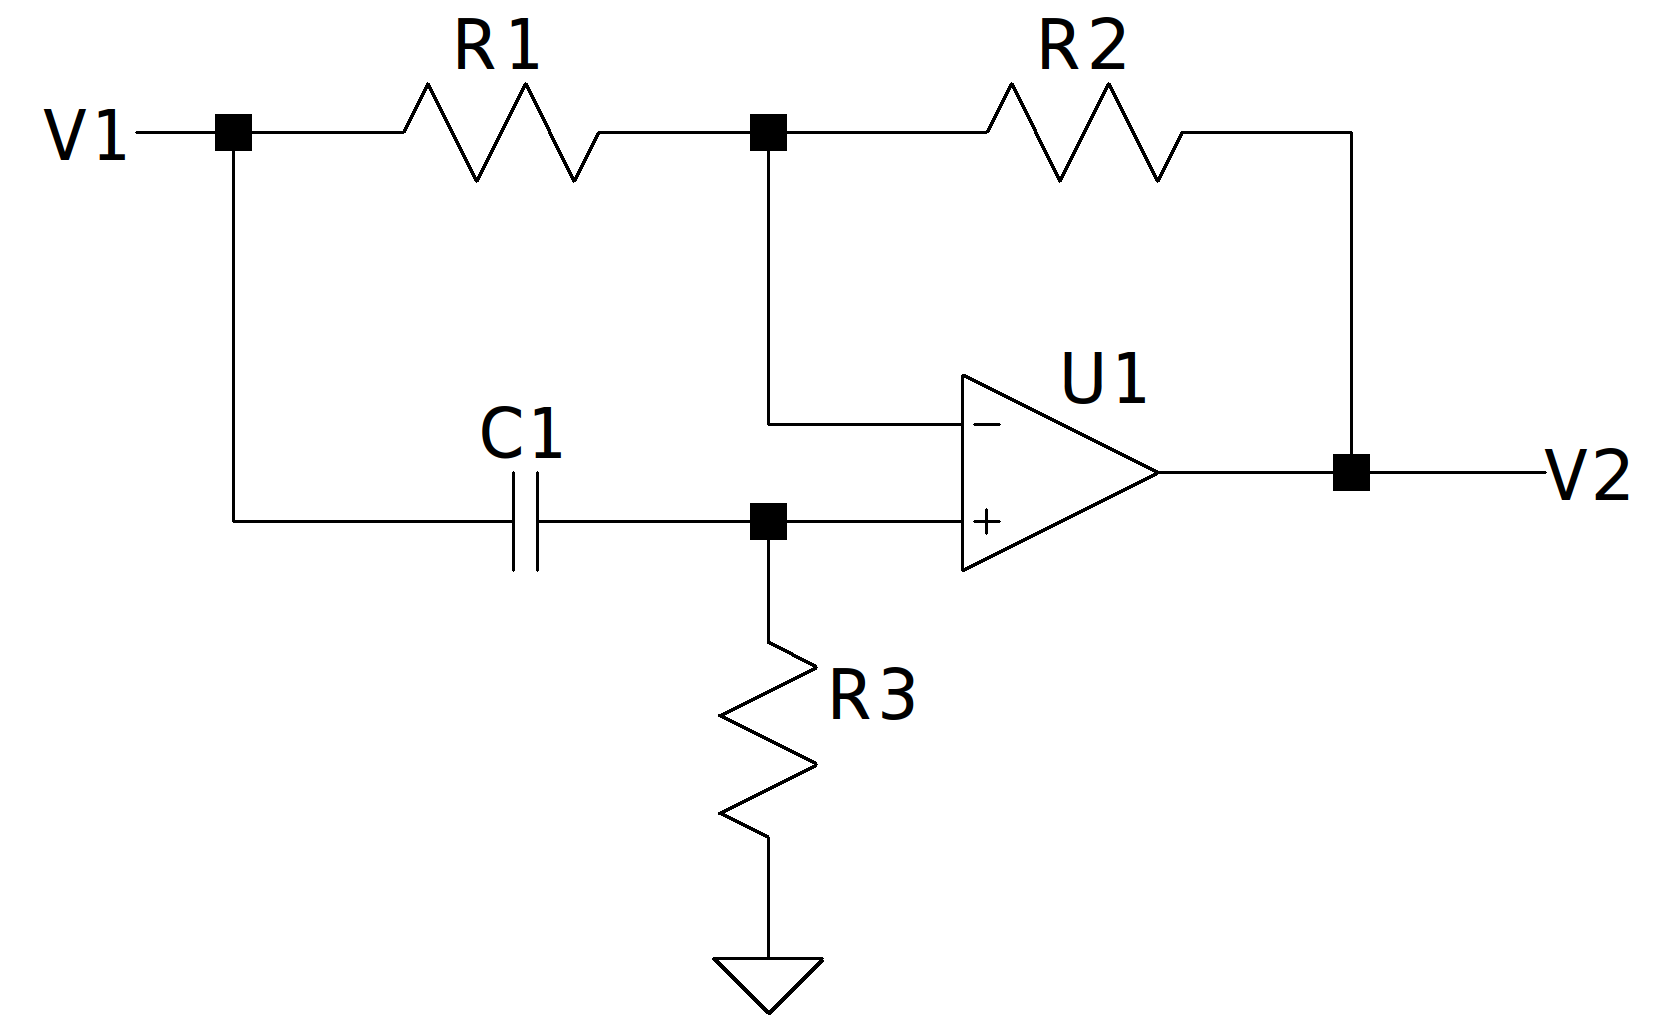
</div>

Se pide obtener la función transferencia, realizando los diagramas de polos y ceros, módulo y fase considerando $\frac{R1}{R2} = 1$, o lo que es lo mismo, $R1 = R2$. 

A su vez, se va a normalizar la red, encontrando una norma de impedancia $\Omega_z$ y la norma de frecuencia $\Omega_\omega$.

Finalmente, se realizarán las simulaciones correspondientes con LTSPice y en Python.

## Resolución del circuito

### Análisis por nodos del circuito

Comienzo por nombrar a los nodos que voy a analizar.

<div style="text-align: center;">
  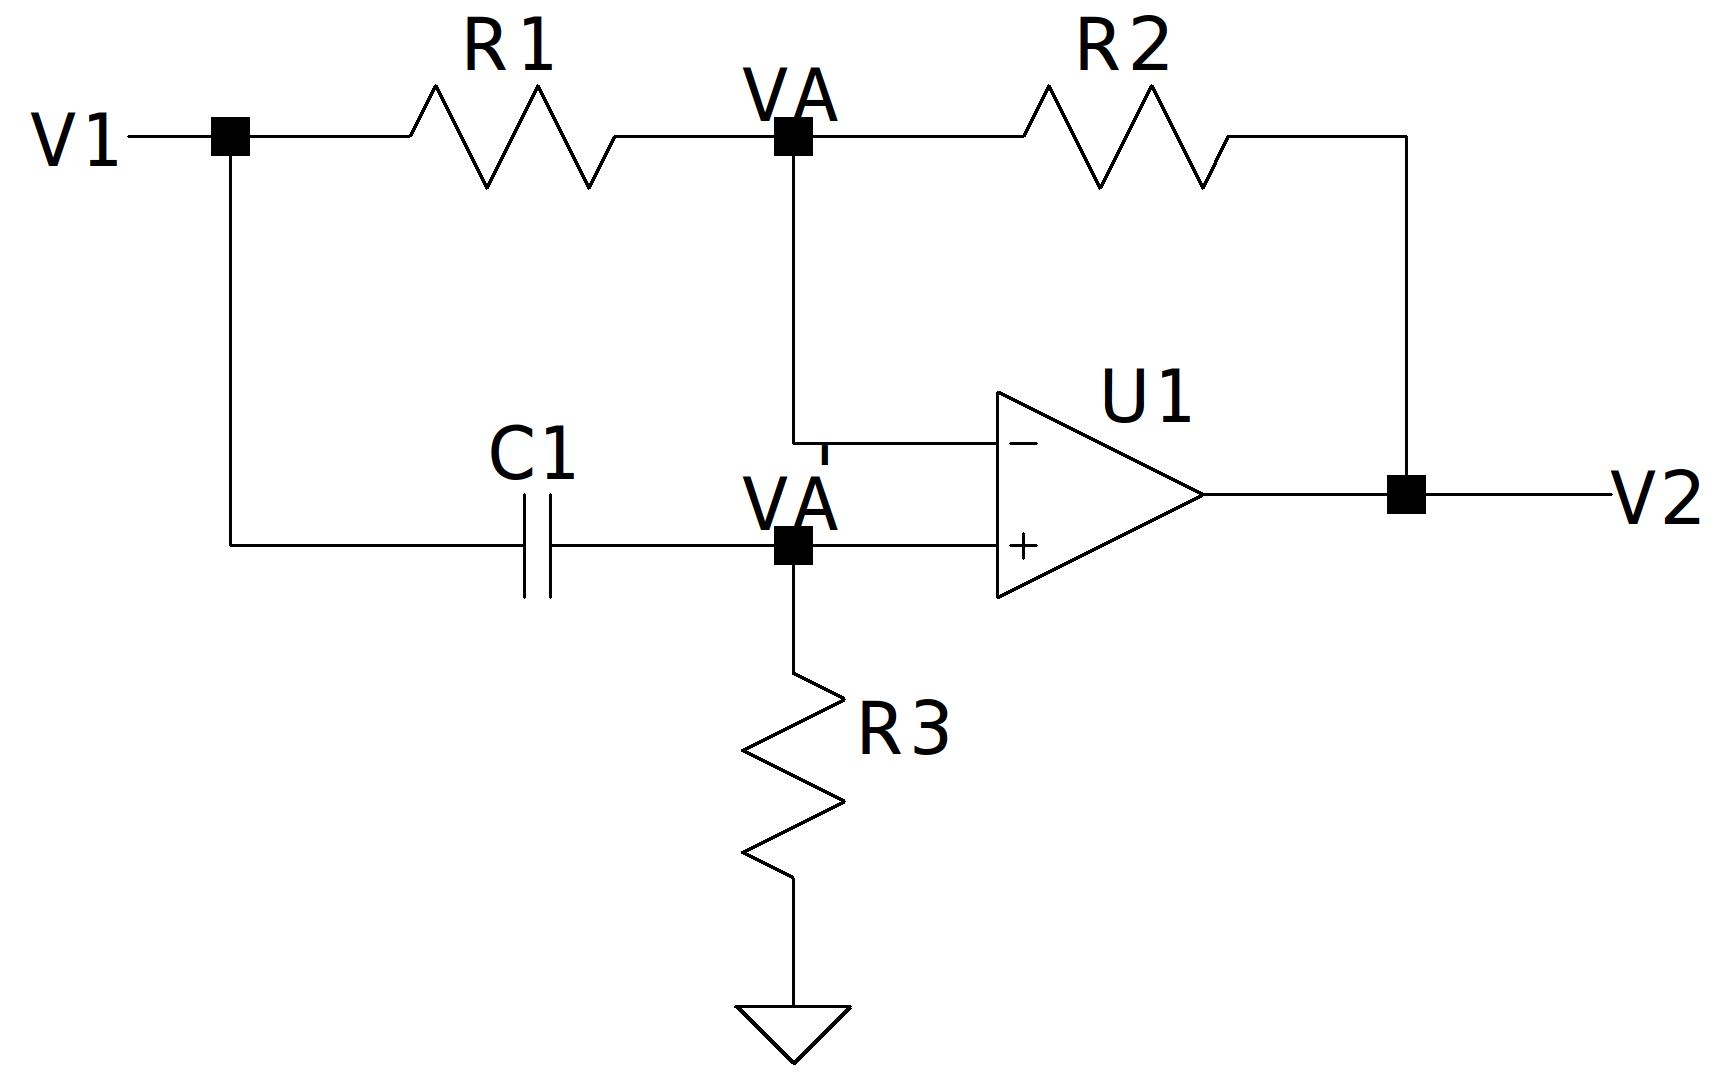
</div>

En este caso, como se trata de un amplificador operacional ideal y está realimentado negativamente se puede demostrar que en un amplificador con realimentación negativa, la señal de error $V^{+} - V^{-}$ resulta proporcional a $\large \frac{1}{1 + A\beta}$, por lo tanto, si la ganancia es muy grande ($A\beta >>> 1$), dicha diferencia tiende a cero, cumpliéndose que:
$$V^{+} \approx V^{-}$$.

Por lo cual se puede decir que la tensión:
$$V_A \approx V_A'$$
Y para todo este análisis se tomará directamente que:
$$V_A = V_A'$$

Habiendo dicho esto, planteo las ecuaciones:

$$(1)\  0 = V_A . (G1 + G2) - V_1 . (G1) - V2 . (G2) $$

$$(2)\ 0 = V_A . (G3 + s . C1) - V_1 . (s . C1) $$

Despejando $V_A$ en (2):

$$V_A = \frac {V_1.(s.C1)}{G3 + s.C1}$$

Ahora, colocando este resultado en (1):

$$0 = \frac {V_1.(s.C1)}{G3 + s.C1} . (G1 + G2) - V_1 . (G1) - V2 . (G2)$$

Cómo busco obtener $\large T(s) = \frac {V_2}{V_1}$ continúo despejando hasta llegar a la siguiente función transferencia:

$$ T(s) = \frac {s.C1.(G1 + G2) - G1.(G3 + s.C1)}{G2.(G3+s.C1)}$$

Aplicando la condición de *$R1 = R2$* impuesta por el enunciado y operando adecuadamente obtengo:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
      $$ \Large T(s) = \frac{s - \frac{G3}{C1}}{s + \frac{G3}{C1}} $$
    </div>
</div>

De aquí puedo decir que:
$$\large \omega_0 = \frac{G3}{C1}$$

### Diagramas

Para obtener los polos y ceros analizo la función transferencia $T(s)$.

En este caso, tanto para esto como para el módulo y fase lo simularé con python, usando la biblioteca de *numpy*.

Imponiendo los valores de $G3$ y $C1$.
$$G3 = 1mS$$
$$C1 = 1\mu F$$

Y mediante el siguiente código obtengo los gráficos.

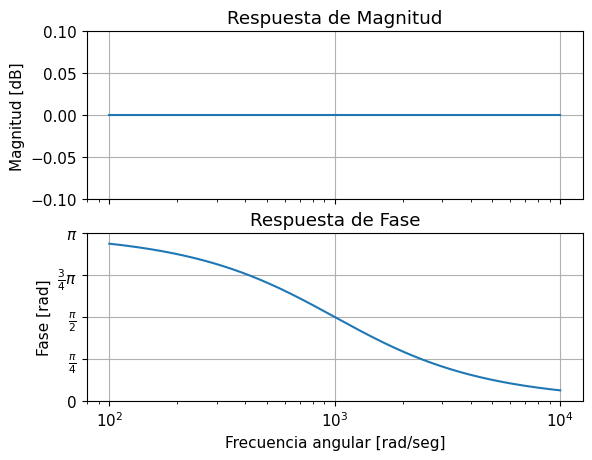

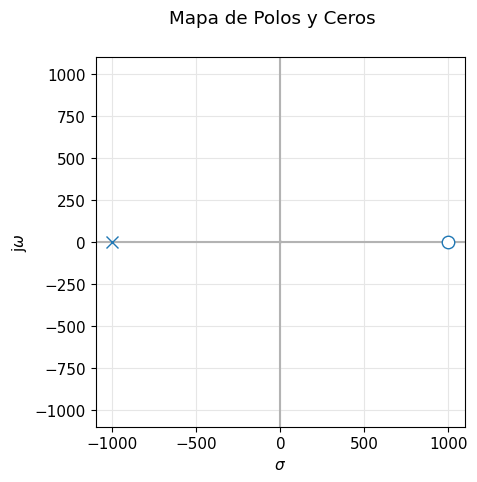

In [16]:
import scipy.signal as sig
import matplotlib.pyplot as plt
import numpy as np

from pytc2.sistemas_lineales import bodePlot, pzmap

g3 = 0.001
c1 = 0.000001

a = g3 / c1

T = sig.TransferFunction([1, -a], [1, a])
bodePlot(T, fig_id=1)
axs = plt.figure(1).axes
axs[0].set_ylim([-0.1, 0.1])

pzmap(T, fig_id=2)

plt.show()

En base al gráfico del módulo se puede ver que el filtro no tendrá ganancia, y la fase comenzará en $\pi$ y por ser un filtro de primer orden, decrecerá a razón de 20dB por décadas, comenzando 1 década antes de $\omega_0$ y terminando 1 década después, llegando a 0. 
Esto es un **filtro pasatodo de 1er orden**.

En caso de querer comprobarlo matemáticamente sin ayuda del simulador se pueden expresar las ecuaciones suponiendo $s = j\omega$, quedando:

$$\large T(s = j\omega) = \frac{jw - \frac{G3}{C1}}{jw + \frac{G3}{C1}}$$

Entonces, si busco obtener el módulo debo hacer tanto en el numerador y denominador:
$$\sqrt{\operatorname(Re)^2 + \operatorname(Im)^2}$$

Obteniendo:

$$
\large |T| = \frac{\sqrt{\left(\frac{G_3}{C_1}\right)^2 + \omega^2}}
{\sqrt{\left(\frac{G_3}{C_1}\right)^2 + \omega^2}} = 1
$$

Y para la fase tengo que hacer tanto para el numerador y el denominador:
$$\arctan{\frac{\operatorname(Im)}{\operatorname(Re)}}$$

Al resolver eso con valores clave tales como $\large \omega = 0$, $\large \omega \rightarrow \infty$ y $\large \omega = \omega_0 = \frac{G3}{C1}$

Se obtiene que:
$$\large \theta_T (\omega = 0) = 0$$
$$\large \theta_T (\omega = \omega_0) = -\frac{\pi}{2}$$
$$\large \theta_T (\omega \rightarrow \infty) = -\pi$$

Dibujando a mano alzada los gráficos:
<div style="text-align: center;">
  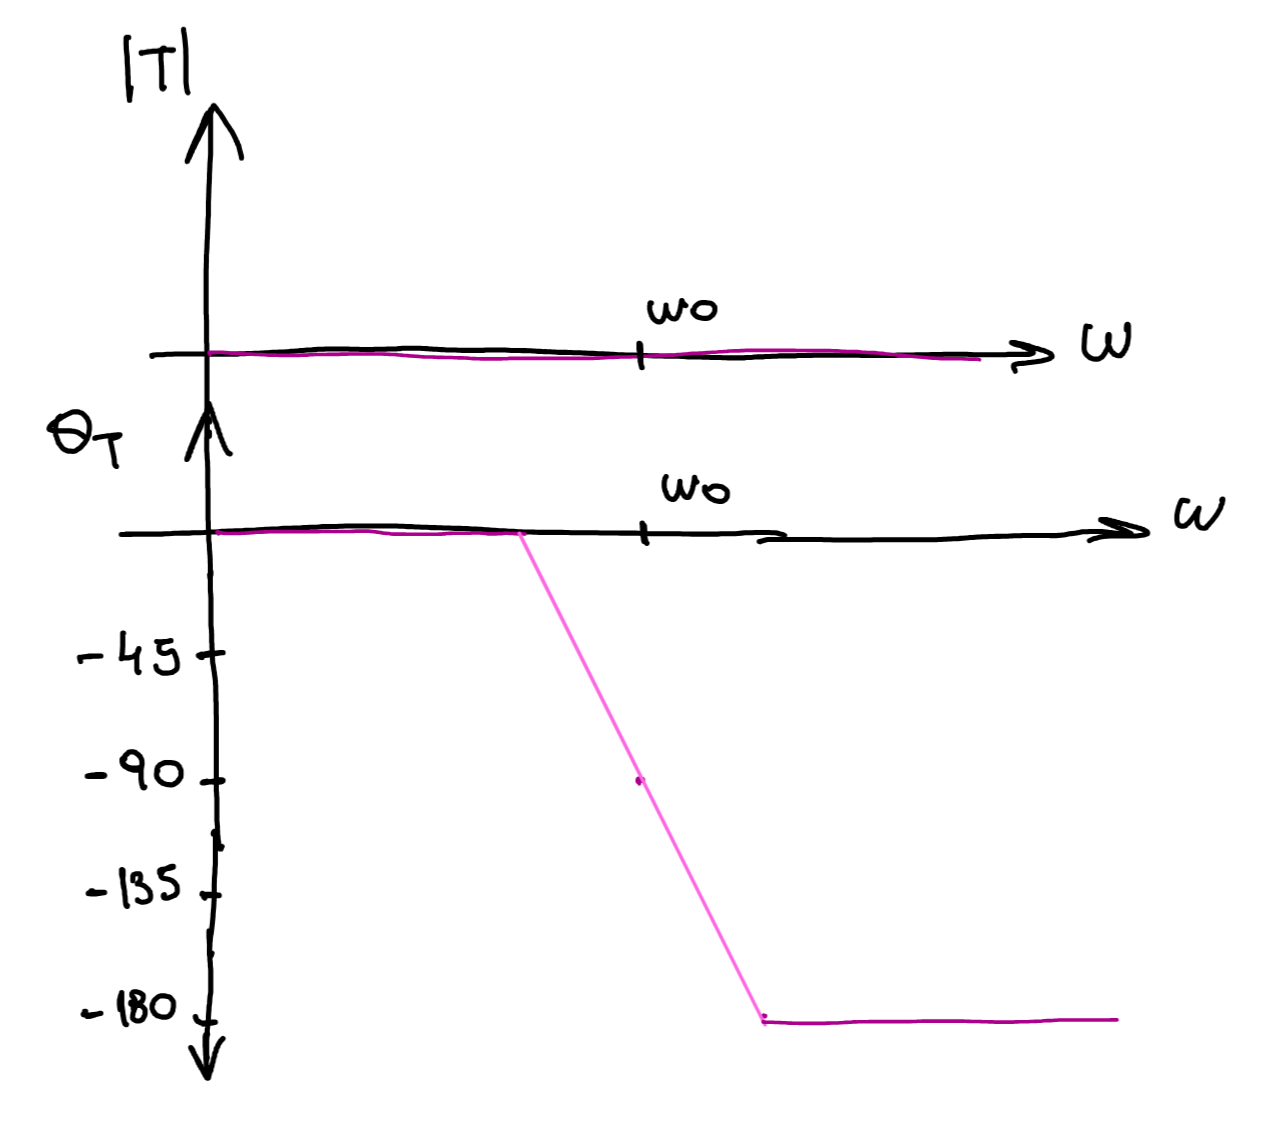
</div>

Comprobando lo mismo que se vio con la simulación.

**Nota**: En este análisis se comenzó desde los 0 grados, en cambio, la simulación comienza en $\pi$.



## Normalización

Volviendo a la transferencia $T(s)$ de antes:
$$ \large T(s) = \frac{s - \frac{G3}{C1}}{s + \frac{G3}{C1}} $$

$$\omega_0 = \frac{G3}{C1}$$

Entonces puedo reescribir mi transferencia $T(s)$ de la siguiente manera:
$$ \large T(s) = \frac{s - \omega_0}{s + \omega_0} $$

Lo que voy a hacer ahora es imponer una norma de frecuencia $\large \Omega_\omega = 1$. Esto implica en el diagrama de polos y ceros que el radio de mi circunferencia es unitario.

<div style="text-align: center;">
  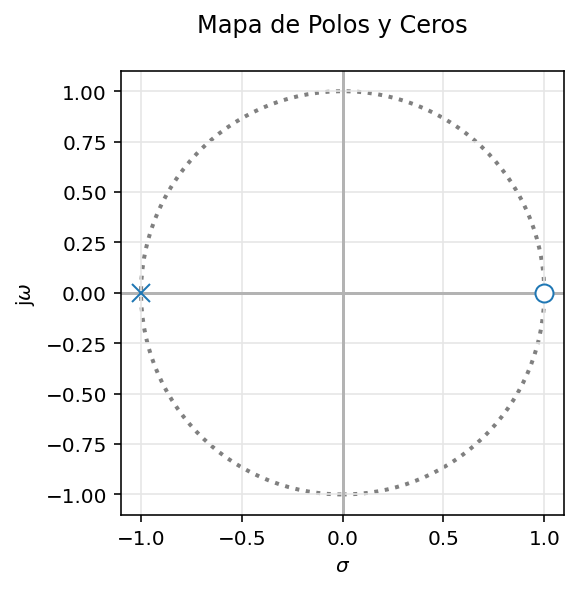
</div>

Y a su vez, la transferencia queda:
$$ \large T(s) = \frac{s - 1}{s + 1} $$

Entonces:
$$\large \omega_0 = \frac{G3}{C1} = \frac{1}{R3.C1} = 1$$

Imponiendo el valor de $R3 = 1.K\Omega$ despejo $C1 = 1mF$.

Y como mi transferencia solo está afectada por $R3$ directamente impongo que la norma de impedancia $\large \omega_z = R3 = 1K\Omega$

Por lo que, como mi norma de impedancia es $\large \omega_z = 1K \Omega$, tengo que hacer que todas mis resistencias dependan de esa norma. En este caso, lo más sencillo es hacer que todas mis resistencias valgan $1K\Omega$

### Circuito Normalizado

Por lo tanto los valores de los componentes para mi circuito normalizado son:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$ \Large R1 = R2 = R3 = 1K\Omega$$
        $$ \Large C1 = 1mF$$
    </div>
</div>

Llevándolo al circuito:
<div style="text-align: center;">
  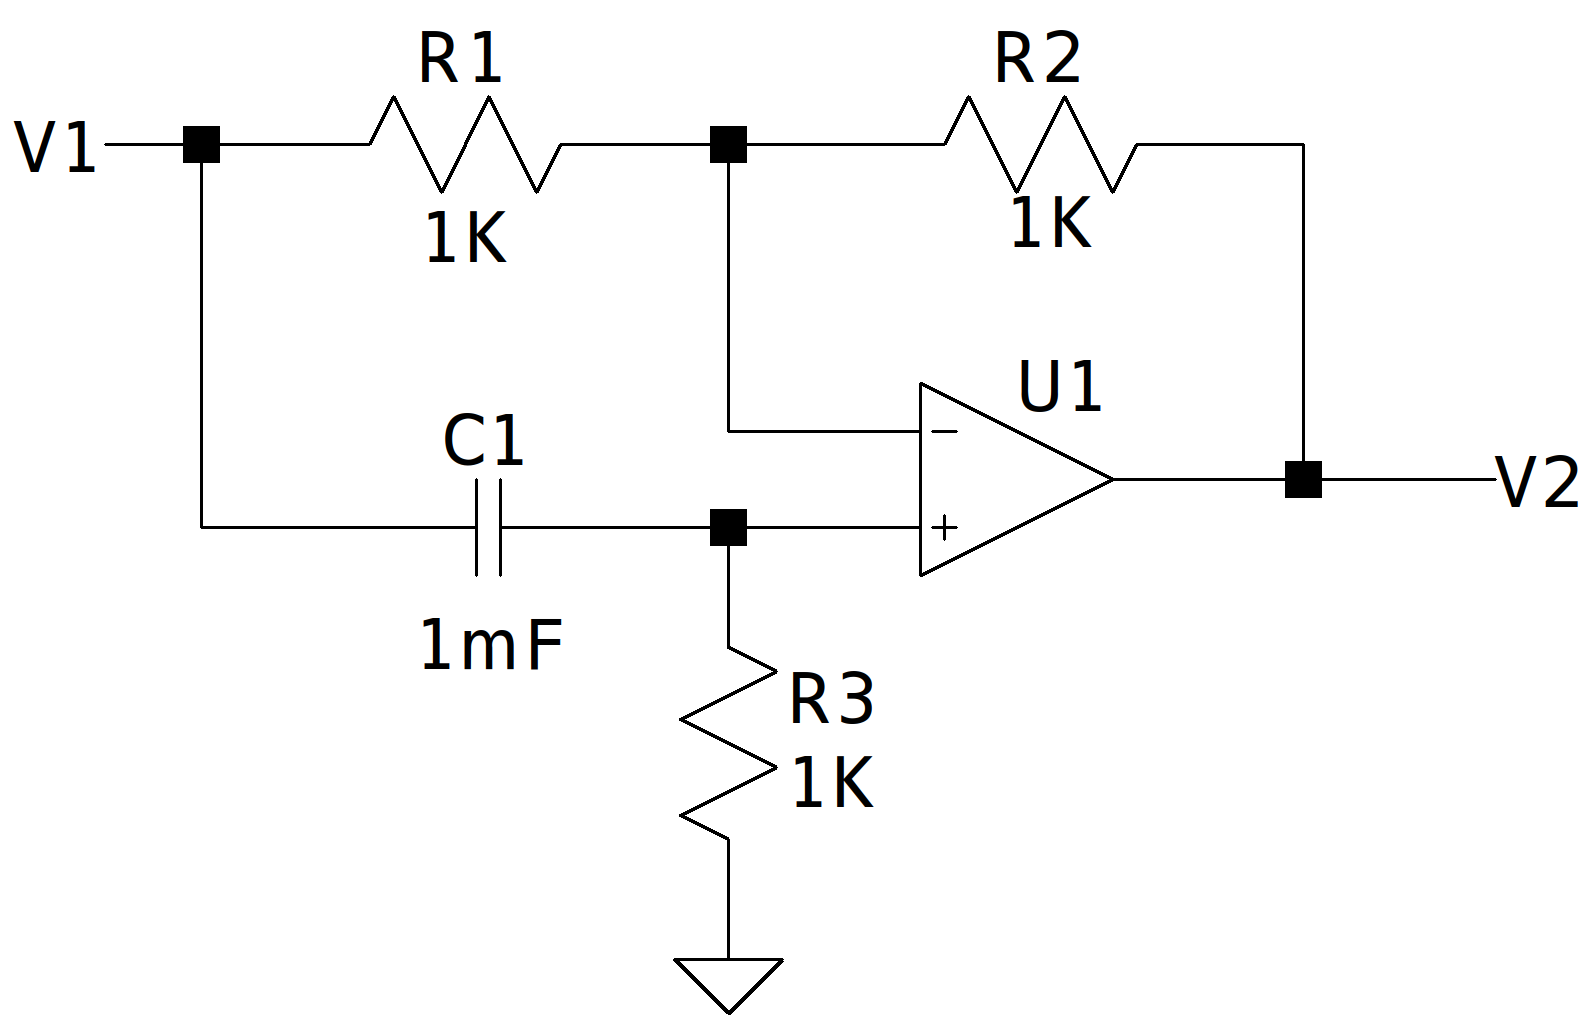
</div>

#### Respuesta en frecuencia
Simulo el circuito con las siguientes directivas de LTSpice:
`.ac dec 1000 1 1Meg` y colocando un generador como entrada de $V_1$ con una amplitud de 1.

Esto significa que haré un análisis frecuencial desde $1Hz$ hasta $1MHz$ con 1000 puntos por década.
Se muestra el resultado de la respuesta en frecuencia a continuación:

##### Módulo
<div style="text-align: center;">
  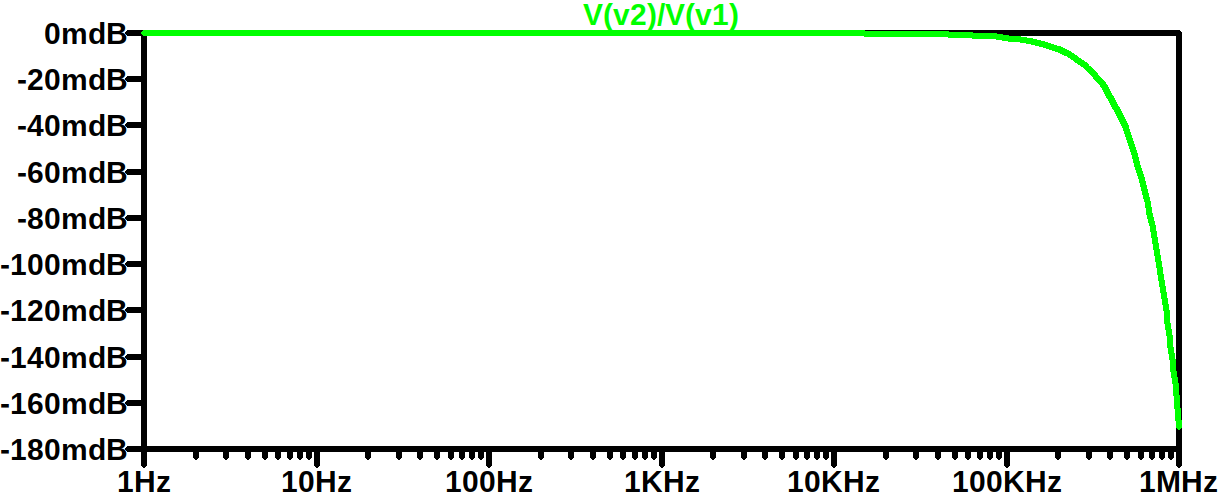
</div>

##### Fase
<div style="text-align: center;">
  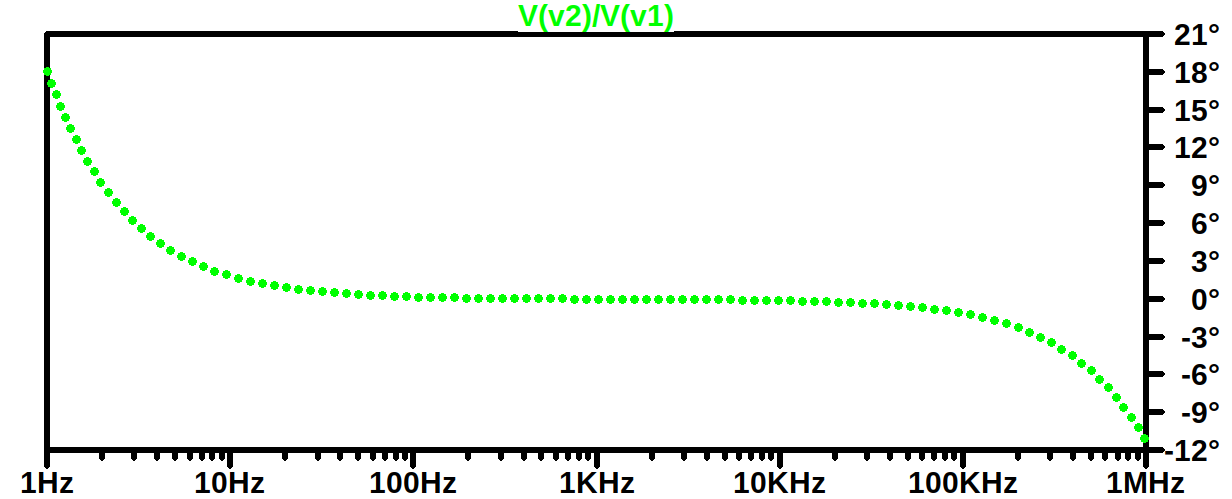
</div>

#### Simulación en Python
Ahora simulo con **numpy** con esos valores.

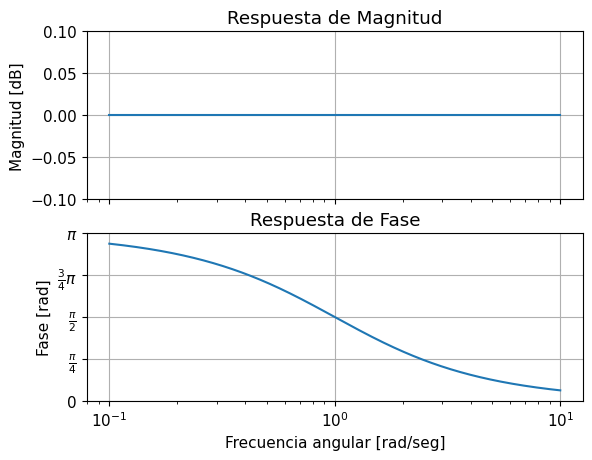

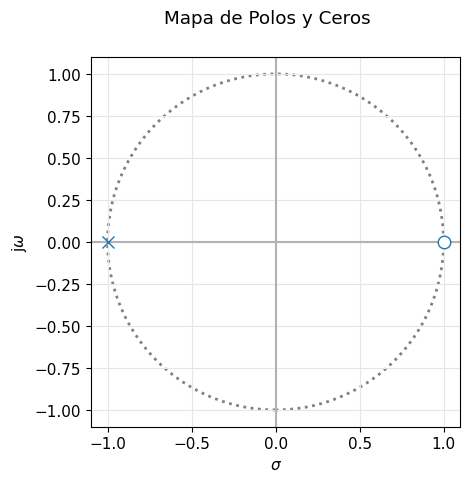

In [17]:
import scipy.signal as sig
import matplotlib.pyplot as plt
import numpy as np

from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay

g3 = 0.001
c1 = 0.001

a = g3 / c1

T = sig.TransferFunction([1, -a], [1, a])
bodePlot(T, fig_id=1)
axs = plt.figure(1).axes
axs[0].set_ylim([-0.1, 0.1])

pzmap(T, fig_id=2)

plt.show()


Consiguiendo los gráficos de módulo y fase iguales a los obtenidos antes de normalizar, con la diferencia de tener el polo y el cero en -1 y 1 respectivamente.

### Comparación con Ejercicios de la guía

Se pedía comparar con el ejercicio 7 de la guía de OPAMPs y OTAs.
En ese ejercicio se presentaban dos circuitos. El primero era un caso particular del circuito que se está analizando en esta tarea, ya que simplemente se le daban valores al circuito que se resolvió arriba.

Por otro lado, está el siguiente circuito:

<div style="text-align: center;">
  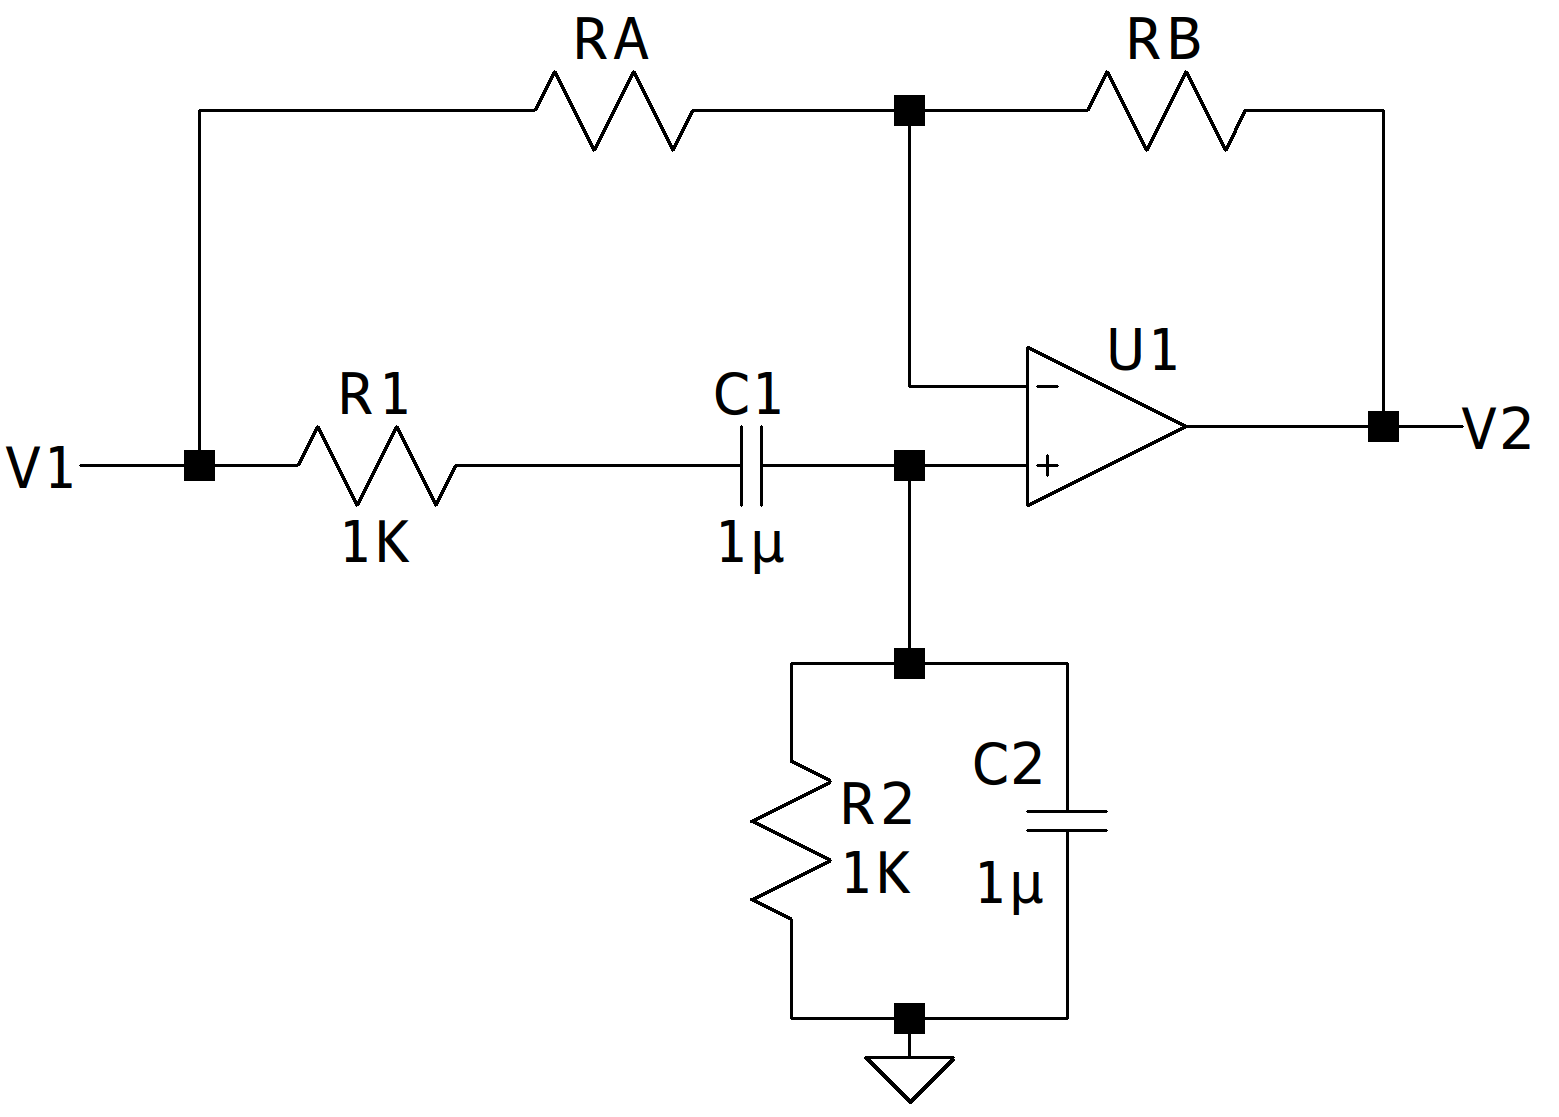
</div>

Resolviendo su transferencia $T(s)=\frac{V2}{V1}$ se obtiene lo siguiente:


<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$\Large T(s)=\frac{1}{5}\frac{-S^2.C^2 + 3SCG-G^2}{S^2.C^2 + 3SCG+G^2}$$
    </div>
</div>

Con lo que ya se puede ver que su amplitud será de $\frac{1}{5}$. O sea, expresado en dB es $\large 20.log(\frac{1}{5}) = -13,97dB$.

Por otro lado, para obtener su fase, directamente lo que haré es simular el circuito en LTSpice con los valores brindados en la consigna y asumiendo $RA=5K\Omega$ y $RB=1K\Omega$ para cumplir con la condición de la consigna. 

##### Módulo
<div style="text-align: center;">
  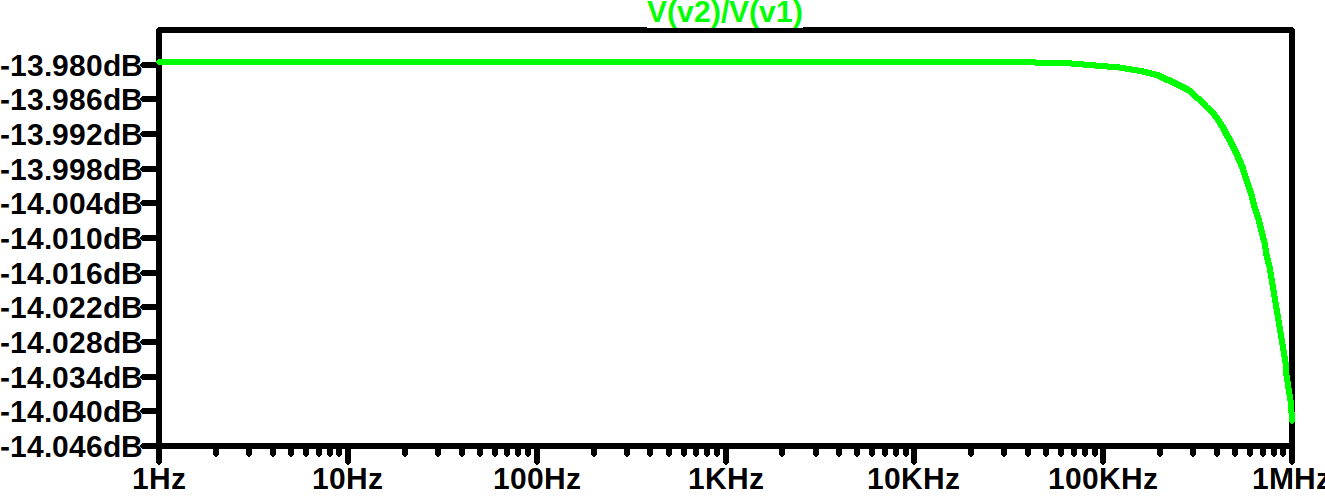
</div>

##### Fase
<div style="text-align: center;">
  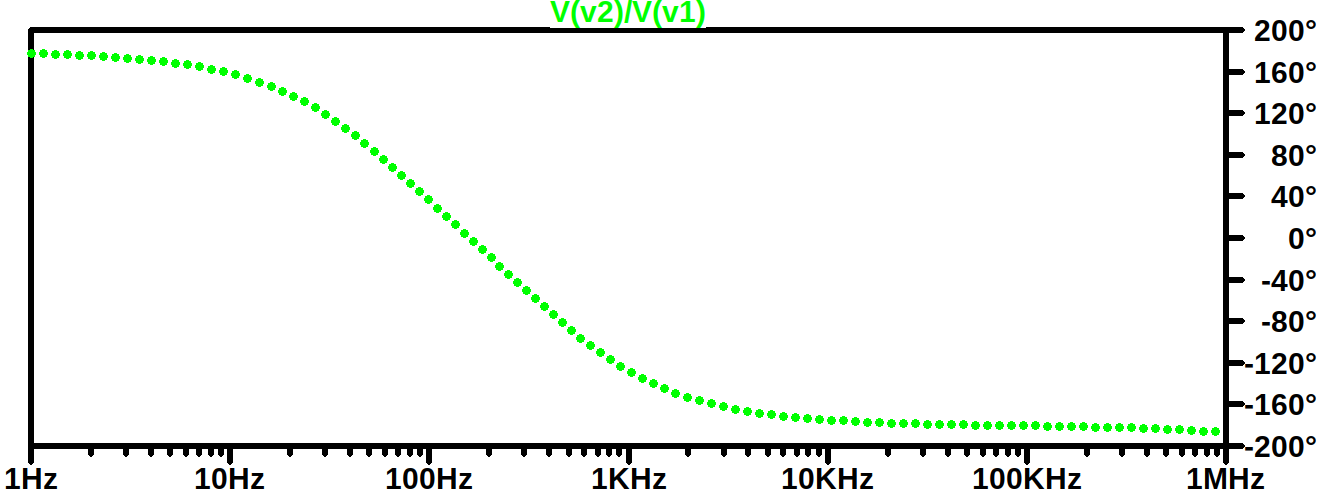
</div>

Analizando estos valores en código de Python también se obtiene:

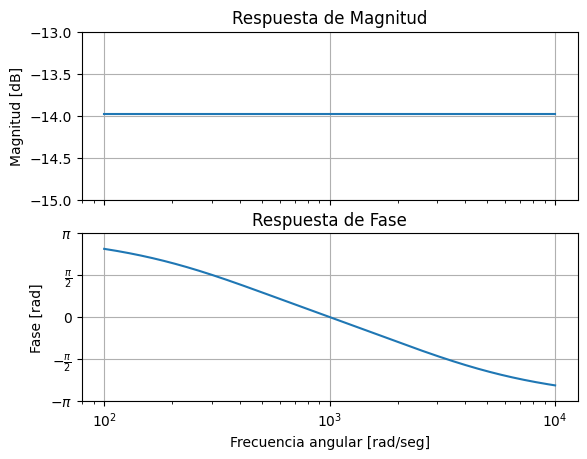

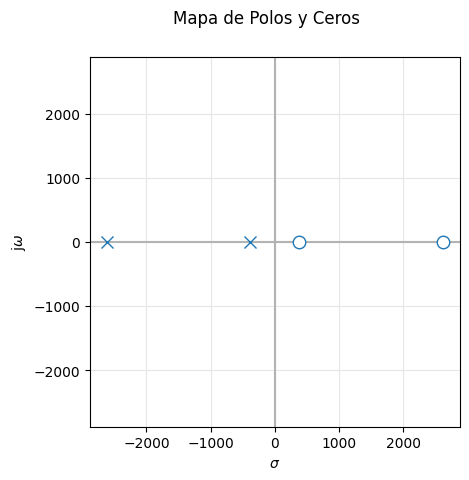

In [1]:
import scipy.signal as sig
import matplotlib.pyplot as plt
import numpy as np

from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay

# Valores
R = 1e3
C = 1e-6

w0 = 1 / (R * C)

# Numerador y denominador
num = [-1, 3*w0, -w0**2]
den = [1, 3*w0, w0**2]

# Ganancia 1/5
k = 1/5
num = [k * x for x in num]

T = sig.TransferFunction(num, den)

# Bode
bodePlot(T, fig_id=1)
axs = plt.figure(1).axes
axs[0].set_ylim([-15, -13])  # módulo ~ -14 dB

# Polos y ceros
pzmap(T, fig_id=2)

plt.show()

El resultado obtenido es consistente con los diagramas de módulo y fase. En particular, el módulo se mantiene constante, lo cual confirma que se trata de un filtro pasatodo.

Por otro lado, el diagrama de polos y ceros aporta información adicional relevante. Al tener dos polos y dos ceros simétricos a esos polos en el otro semiplano, se puede ver que el sistema es de segundo orden. Lo cual es lógico por los  dos elementos reactivos en el circuito.

Además, la disposición de polos y ceros permite interpretar al sistema como la cascada de dos filtros pasatodo de primer orden.

Por último, en este caso la fase varía desde $\pi$ hasta $-\pi$ y no desde $\pi$ hasta 0 como en el filtro de 1er orden, lo cual es lógico por la presencia de la otra etapa.